In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
np.random.seed(0)
from sklearn.metrics import precision_score,recall_score,f1_score
import tensorflow as tf
tf.compat.v1.set_random_seed(0)
from tensorflow import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

In [4]:
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/drebin-215.csv")
print("Total missing values : ",sum(list(data.isna().sum())))
data

/tmp/ipykernel_2124/2928500238.py:1: DtypeWarning: Columns (92) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/drebin-215.csv")


Total missing values :  0


,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,S
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,S
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,S
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15031,1,1,1,1,1,1,0,1,1,1,...,0,0,0,1,1,0,0,0,0,B
15032,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,0,0,0,0,B
15033,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,B
15034,1,1,1,1,1,1,0,1,1,1,...,1,0,0,1,1,1,0,0,0,B


In [7]:
classes,count = np.unique(data['class'],return_counts=True)# Get unique classes and their counts from the 'class' column


lbl_enc = LabelEncoder() #Initialize a LabelEncoder to encode class labels as integers
print(lbl_enc.fit_transform(classes),classes) # Fit label encoder to the  classes and print the transformed values along with the

data = data.replace(classes,lbl_enc.fit_transform(classes)) # replace the class in dataset with encoded integer


data=data.replace('[?,S]',np.nan,regex=True) # regex=regular expression method to replace '[?,S]'patterns with NaN

print("Total missing values : ",sum(list(data.isna().sum())))
data.dropna(inplace=True)  # drop nan
for c in data.columns:
    data[c] = pd.to_numeric(data[c])  #convert alll values to numeric
data

[0 1] [0 1]
Total missing values :  5


,transact,onServiceConnected,bindService,attachInterface,ServiceConnection,android.os.Binder,SEND_SMS,Ljava.lang.Class.getCanonicalName,Ljava.lang.Class.getMethods,Ljava.lang.Class.cast,...,READ_CONTACTS,DEVICE_POWER,HARDWARE_TEST,ACCESS_WIFI_STATE,WRITE_EXTERNAL_STORAGE,ACCESS_FINE_LOCATION,SET_WALLPAPER_HINTS,SET_PREFERRED_APPLICATIONS,WRITE_SECURE_SETTINGS,class
0,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,1,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15031,1,1,1,1,1,1,0,1,1,1,...,0,0,0,1,1,0,0,0,0,0
15032,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,1,0,0,0,0,0
15033,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,0,0,0
15034,1,1,1,1,1,1,0,1,1,1,...,1,0,0,1,1,1,0,0,0,0


Total Features :  215


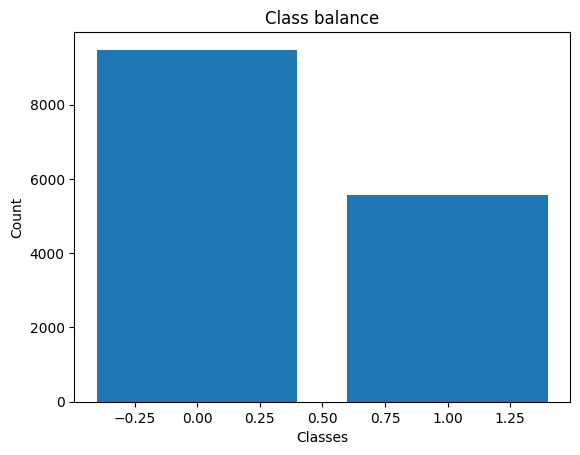

In [8]:
print("Total Features : ",len(data.columns)-1)
plt.bar(classes,count)
plt.title("Class balance")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.show()

In [9]:
from sklearn.utils import resample
#identify feature and target class
X = data.drop("class", axis=1)# removes class column from dataset and keeps only features
y = data["class"] # keeps only class values and removes other values

class_counts = y.value_counts() #total count of class

majority_class = class_counts.idxmax() # highest count classes (majority)
minority_class = class_counts.idxmin() # lowest count classes (minority)


#Separate the samples of majority and minority classes

majority_samples = data[data["class"] == majority_class]
minority_samples = data[data["class"] == minority_class]


# apply oversampling on the minority class to match the size of the majority class

minority_oversampled = resample(minority_samples,  # minority class data
                                 replace=True,   # resampling with replacement
                                 n_samples=len(majority_samples),  # Match number of majority samples
                                 random_state=0)
# combine the oversampled minority class data with the original majority class data
balanced_data = pd.concat([majority_samples, minority_oversampled])

# randomize the order of samples in the combined dataet
balanced_data = balanced_data.sample(frac=1, random_state=0)

In [10]:
balanced_class_counts = balanced_data["class"].value_counts()

print(balanced_class_counts)

class
1    9476
0    9476
Name: count, dtype: int64


In [11]:
TEST_SPLIT = 0.25
from sklearn.model_selection import train_test_split
train_x,test_x,train_y,test_y = train_test_split(data[data.columns[:len(data.columns)-1]].to_numpy(),
                                                 data[data.columns[-1]].to_numpy(),
                                                  test_size = TEST_SPLIT,
                                                  shuffle=True)
print("Train features size : ",len(train_x))
print("Train labels size : ",len(train_y))
print("Test features size : ",len(test_x))
print("Test features size : ",len(test_y))

print("Train features : ",train_x.shape)
print("Train labels : ",train_y.shape)
print("Test Features : ",test_x.shape)
print("Test labels : ",test_y.shape)

train_y = train_y.reshape((-1,1))
test_y = test_y.reshape((-1,1))

print("Train features : ",train_x.shape)
print("Train labels : ",train_y.shape)
print("Test Features : ",test_x.shape)
print("Test labels : ",test_y.shape)

Train features size :  11273
Train labels size :  11273
Test features size :  3758
Test features size :  3758
Train features :  (11273, 215)
Train labels :  (11273,)
Test Features :  (3758, 215)
Test labels :  (3758,)
Train features :  (11273, 215)
Train labels :  (11273, 1)
Test Features :  (3758, 215)
Test labels :  (3758, 1)


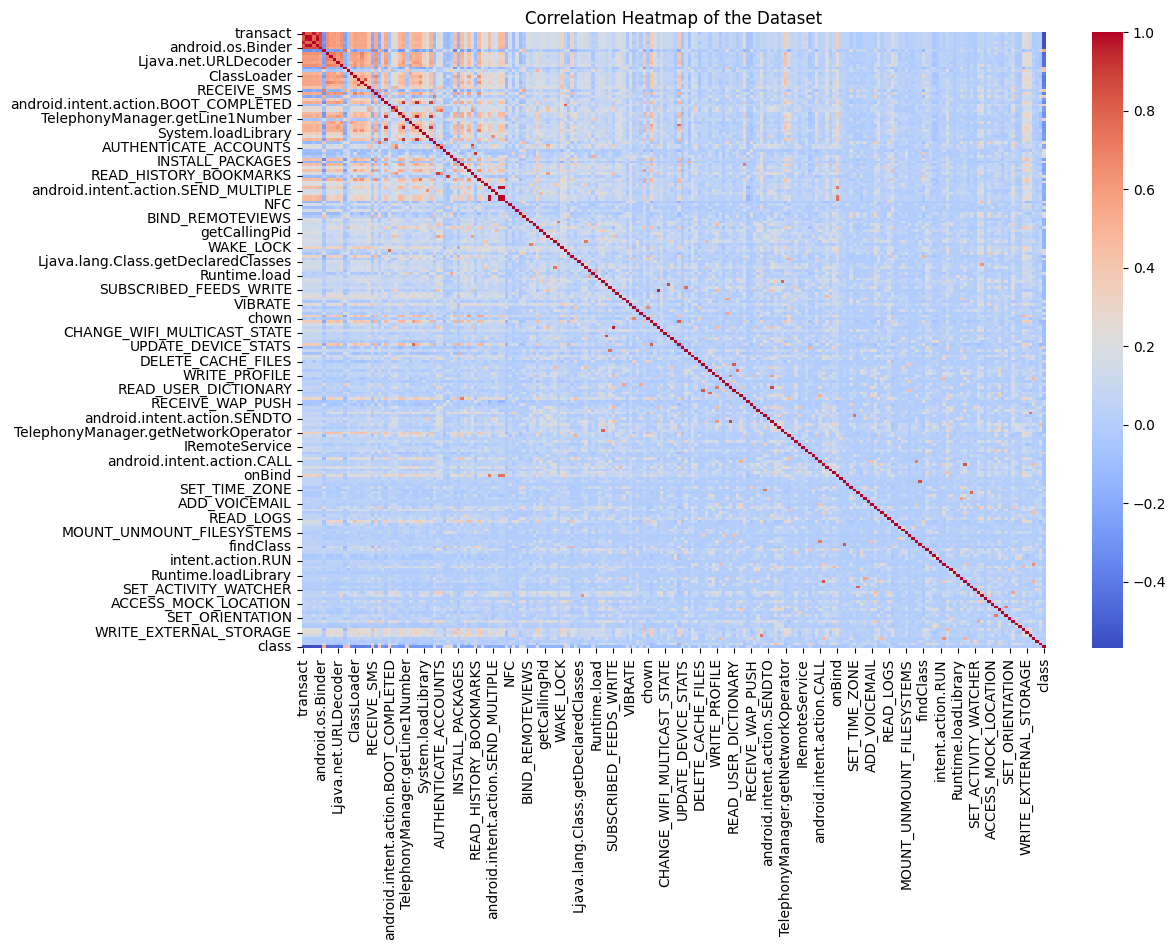

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 8))
heatmap = sns.heatmap(data.corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap of the Dataset")
plt.show()

In [ ]:
from sklearn.model_selection import KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np


k_folds = 5
batch_size = 2
epochs = 20
all_scores = []

kfold = KFold(n_splits=k_folds, shuffle=True, random_state=42) # define k-fold

X = train_x.reshape((train_x.shape[0], train_x.shape[1], 1))  # Reshape input for Conv1D
y = train_y

for train_idx, val_idx in kfold.split(X): # loop each fold
    X_train, X_val = X[train_idx], X[val_idx] # features for training and vlidation
    y_train, y_val = y[train_idx], y[val_idx] # labels for training and validation

#Conv1D based sequential model

    model = Sequential([
        Conv1D(64, kernel_size=3, activation='relu', input_shape=(215, 1)),# 1d conv filter slides to extract the features
        MaxPooling1D(pool_size=2),
        Conv1D(128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5), # Regularization to handle overfitting
        Dense(1, activation='sigmoid') # binary classification using sigmoid
    ])


    # Compile model with Adam optimizer, binary cross-entropy loss, and accuracy metric
    model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

    #train the final model
    model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_val, y_val), verbose=0)


    #evaluate the model
    score = model.evaluate(X_val, y_val, verbose=0)
    print(f"Fold validation accuracy: {score[1]}")
    all_scores.append(score[1])  # append the score for each fold

average_accuracy = np.mean(all_scores)
print(f"Average cross-validation accuracy: {average_accuracy}")


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold validation accuracy: 0.9889135360717773
Fold validation accuracy: 0.9853658676147461
Fold validation accuracy: 0.9791574478149414
Fold validation accuracy: 0.986246645450592


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
import numpy as np

class GraphConvolution(Layer):
    def __init__(self, output_dim, **kwargs):
        self.output_dim = output_dim
        super(GraphConvolution, self).__init__(**kwargs)

    def build(self, input_shape):  #line12-18 is weight initialization process

        self.kernel = self.add_weight(name='kernel',    #Creates a trainable weight matrix by using input shape, initializer
                                      shape=(input_shape[0][-1], self.output_dim),
                                      initializer='glorot_uniform',   #glorot_uniform initialization ensures good weight initialization.
                                      trainable=True)
        super(GraphConvolution, self).build(input_shape)

    def call(self, inputs):  #line 20 -25 is forward pass
        x, adj = inputs # input -> feature matrix and its adjacency matrix to show the graph connectivty

        x = tf.matmul(adj, x) # multiply adjacency matrix
        output = tf.matmul(x, self.kernel)  # multiply the learned weight with the aggregated features
        return tf.nn.relu(output)  #ReLU activation to introduce non-linearity.

num_features = train_x.shape[1] # get training fatures

input_features = Input(shape=(num_features, 1), name="input_features")   # data in the form of tensor to represent the features of the nodes in the graph.
input_adj = Input(shape=(num_features, num_features), name="input_adj") #tensor representing the adjacency matrix of the graph


# adding graph convolutions
x = GraphConvolution(64)([input_features, input_adj])  # takes features from previous layer and adjacency matrix remains constant
x = GraphConvolution(32)([x, input_adj])  # first layer produces 64-dimensional features for each node and recond layer refines in 32


x = Flatten()(x)  #Flatten the graph's node features into a vector
output = Dense(1, activation='sigmoid')(x)  # Outputs a single value with a sigmoid activation for binary classification

model = Model(inputs=[input_features, input_adj], outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

X_train_expanded = train_x.reshape(-1, num_features, 1) #Expands the feature data to match the input shape
X_test_expanded = test_x.reshape(-1, num_features, 1)

A_normalized = np.eye(num_features)
A_train_batch = np.tile(A_normalized, (X_train_expanded.shape[0], 1, 1))

model.fit([X_train_expanded, A_train_batch], train_y, epochs=20, batch_size=2)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

history = model.fit([X_train_expanded, A_train_batch], train_y, epochs=20, batch_size=2, verbose=1)

A_test_batch = np.tile(A_normalized, (X_test_expanded.shape[0], 1, 1))

test_loss, test_accuracy = model.evaluate([X_test_expanded, A_test_batch], test_y, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred = model.predict([X_test_expanded, A_test_batch])
y_pred_classes = (y_pred > 0.5).astype(int)

print("\nClassification Report:")
print(classification_report(test_y, y_pred_classes))

avg_accuracy = accuracy_score(test_y, y_pred_classes)
print(f"Average Accuracy: {avg_accuracy:.4f}")


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Flatten, Input
from tensorflow.keras.models import Model
import numpy as np

# Define the CNN-LSTM model
num_features = train_x.shape[1]

input_features = Input(shape=(num_features, 1), name="input_features")

x = Conv1D(filters=64, kernel_size=3, activation='relu')(input_features)
x = MaxPooling1D(pool_size=2)(x)

x = LSTM(50, return_sequences=True)(x)
x = LSTM(25)(x)

output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=input_features, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

X_train_expanded = train_x.reshape(-1, num_features, 1)
X_test_expanded = test_x.reshape(-1, num_features, 1)

model.fit(X_train_expanded, train_y, epochs=20, batch_size=32, validation_data=(X_test_expanded, test_y))

test_loss, test_accuracy = model.evaluate(X_test_expanded, test_y, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred = model.predict(X_test_expanded)
y_pred_classes = (y_pred > 0.5).astype(int)

from sklearn.metrics import accuracy_score, classification_report
print("\nClassification Report:")
print(classification_report(test_y, y_pred_classes))


avg_accuracy = accuracy_score(test_y, y_pred_classes)
print(f"Average Accuracy: {avg_accuracy:.4f}")


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import LSTM, Dense, Input
from tensorflow.keras.models import Model
import numpy as np

# Define the LSTM model
num_features = train_x.shape[1]

input_features = Input(shape=(num_features, 1), name="input_features")


x = LSTM(50, return_sequences=True)(input_features)
x = LSTM(25)(x)


output = Dense(1, activation='sigmoid')(x)


model = Model(inputs=input_features, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


X_train_expanded = train_x.reshape(-1, num_features, 1)
X_test_expanded = test_x.reshape(-1, num_features, 1)


model.fit(X_train_expanded, train_y, epochs=20, batch_size=32, validation_data=(X_test_expanded, test_y))


test_loss, test_accuracy = model.evaluate(X_test_expanded, test_y, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

y_pred = model.predict(X_test_expanded)
y_pred_classes = (y_pred > 0.5).astype(int)

from sklearn.metrics import accuracy_score, classification_report
print("\nClassification Report:")
print(classification_report(test_y, y_pred_classes))


avg_accuracy = accuracy_score(test_y, y_pred_classes)
print(f"Average Accuracy: {avg_accuracy:.4f}")


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = balanced_data.drop("class", axis=1)
y = balanced_data["class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('a')

In [ ]:
!pip install pyswarm

In [ ]:
from pyswarm import pso
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def pso_fitness_function(selected_features):

    mask = [int(f) for f in selected_features]  # conver the features into integer
    X_train_pso = X_train.iloc[:, mask] # get train features
    X_test_pso = X_test.iloc[:, mask] #get test features


    rf = RandomForestClassifier(random_state=0) # initiate RF classifeir
    rf.fit(X_train_pso, y_train)  # fit the RF on pso features
    y_pred = rf.predict(X_test_pso)


    return -accuracy_score(y_test, y_pred) # fitness function is minimized in PSO; thus, the negative accuracy score is returned.. negative loss

# Run PSO
num_features = X_train.shape[1] #number of features in the training dataset.
lb = [0] * num_features # lower bound, 0 indicates feature not selected
ub = [1] * num_features# upper bound , 1 indicates feature selected
best_features, _ = pso(pso_fitness_function, lb, ub, maxiter=1)

selected_features_pso = [X_train.columns[i] for i, sel in enumerate(best_features) if sel > 0.5]
#print("Selected features by PSO:", selected_features_pso)

print(f"Total number of features: {num_features}")
print(f"Number of features selected by PSO: {len(selected_features_pso)}")

rf = RandomForestClassifier(random_state=0)
rf.fit(X_train[selected_features_pso], y_train)
feature_weights_pso = rf.feature_importances_

selected_features_with_weights = {feature: weight for feature, weight in zip(selected_features_pso, feature_weights_pso) if weight > 0}
print("\nSelected features with their weights by PSO (excluding zero-weight features):")
for feature, weight in selected_features_with_weights.items():
    print(f"{feature}: {weight:.4f}")

print(f"\nNumber of features with non-zero weights: {len(selected_features_with_weights)}")


In [ ]:
print("Best features selected by PSO (raw output):", best_features)

threshold = 0.7
selected_features_pso = [train_x.columns[i] for i, sel in enumerate(best_features) if sel > threshold]

print(f"Selected features after applying threshold: {selected_features_pso}")

In [ ]:
import numpy as np
import pandas as pd

train_x = pd.DataFrame(train_x)
test_x = pd.DataFrame(test_x)

selected_features_pso = [feature for feature in selected_features_pso if feature in train_x.columns]

print(f"Selected features: {selected_features_pso}")
if not selected_features_pso:
    print("Error: No valid features selected by PSO.")
else:
    selected_indices = [train_x.columns.get_loc(feature) for feature in selected_features_pso]

    train_x_pso = train_x.iloc[:, selected_indices].values
    test_x_pso = test_x.iloc[:, selected_indices].values

    print(f"Train data shape after feature selection: {train_x_pso.shape}")
    print(f"Test data shape after feature selection: {test_x_pso.shape}")

    if train_x_pso.shape[1] > 0:
        num_features_pso = train_x_pso.shape[1]

        X_train_expanded = train_x_pso.reshape(-1, num_features_pso, 1)
        X_test_expanded = test_x_pso.reshape(-1, num_features_pso, 1)

        A_normalized_pso = np.eye(num_features_pso)
        A_train_batch = np.tile(A_normalized_pso, (X_train_expanded.shape[0], 1, 1))

        # GCN model
        input_features = Input(shape=(num_features_pso, 1), name="input_features")
        input_adj = Input(shape=(num_features_pso, num_features_pso), name="input_adj")

        x = GraphConvolution(64)([input_features, input_adj])
        x = GraphConvolution(32)([x, input_adj])
        x = Flatten()(x)
        output = Dense(1, activation='sigmoid')(x)

        model = Model(inputs=[input_features, input_adj], outputs=output)
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        model.fit([X_train_expanded, A_train_batch], train_y, epochs=20, batch_size=2)

        A_test_batch = np.tile(A_normalized_pso, (X_test_expanded.shape[0], 1, 1))
        model.evaluate([X_test_expanded, A_test_batch], test_y)
    else:
        print("Error: No features after selection. Check if the features are correctly selected.")
